In [1]:
import numpy as np
from scipy.optimize import curve_fit

/var/folders/13/_3g2lmwx6xl3zshjv1d7yz4c0000gn/T/ipykernel_682/2115651759.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_sim, pcov_sim = curve_fit(linear_func, sim[:,0], sim[:,1], absolute_sigma=True)


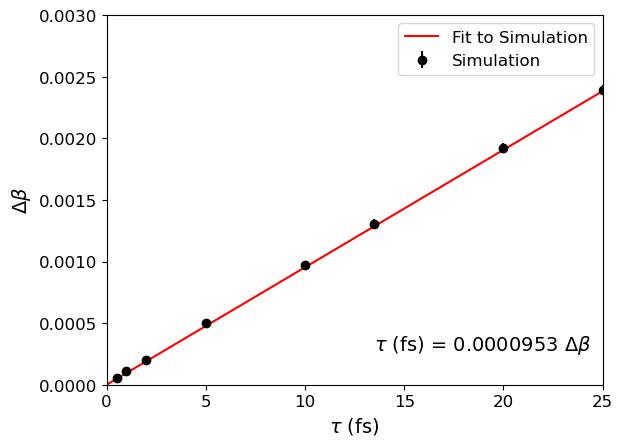

In [ ]:
sim = np.loadtxt('results/simulation.txt', usecols=(0, 1, 2))

# Simulation provides prior on the slope
def linear_func(x, a, b):
    return a * x

# Fit simulation to get prior
popt_sim, pcov_sim = curve_fit(linear_func, sim[:,0], sim[:,1], absolute_sigma=True)

# Plotting
import matplotlib.pyplot as plt

plt.errorbar(sim[:,0], sim[:,1], yerr=sim[:,2], fmt='o', label='Simulation', color='black')
x_fit = np.linspace(0, max(sim[:,0]), 100)
y_fit = linear_func(x_fit, *popt_sim)
plt.plot(x_fit, y_fit, label='Fit to Simulation', color='red')

plt.text(0.54, 0.14, f'$\\tau$ (fs) = {popt_sim[0]:.7f} $\\Delta \\beta$', 
         transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

plt.ylabel(r'$\Delta \beta$', fontsize=14)
plt.xlabel(r'$\tau$ (fs)', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(0, 0.003)
plt.xlim(0, 25)

plt.legend(fontsize=12)
plt.show()